# What is Clustering?

Clustering is an **Unsupervised Machine Learning** technique used to group similar data points together.

Unlike classification, clustering does **not** require labeled data.

The algorithm automatically discovers hidden patterns present in the dataset.

For example,

Suppose a teacher has collected the following student information.

| Student | Study Hours | Exam Marks |
|----------|-------------|------------|
| A | 2 | 30 |
| B | 3 | 35 |
| C | 8 | 90 |
| D | 9 | 95 |

The teacher has **not** labeled students as "Good" or "Average".

The computer must automatically identify similar groups.

This process is called **Clustering**.

# What is K-Means?

K-Means is one of the simplest clustering algorithms.

The algorithm tries to divide the dataset into **K groups (clusters)**.

Each cluster is represented by its center called a **Centroid**.

The objective of K-Means is to minimize the distance between every data point and the centroid of its cluster.

# Real-World Applications

K-Means is widely used in various domains.

Examples include:

- Customer Segmentation
- Student Performance Analysis
- Medical Disease Grouping
- Image Compression
- Market Basket Analysis
- Document Clustering
- Recommendation Systems
- Fraud Detection

In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1.5,2.0],
    [2.0,1.5],
    [2.5,2.5],
    [1.8,3.0],
    [7.5,8.0],
    [8.0,7.5],
    [8.5,8.5],
    [9.0,7.8]
])

print(X)

[[1.5 2. ]
 [2.  1.5]
 [2.5 2.5]
 [1.8 3. ]
 [7.5 8. ]
 [8.  7.5]
 [8.5 8.5]
 [9.  7.8]]


# Visualizing the Dataset

Before applying any clustering algorithm, it is always a good practice to visualize the data.

From the scatter plot, we can observe whether natural groups exist.

Notice that the computer still has **no idea** which points belong together.

It only sees points in a two-dimensional space.

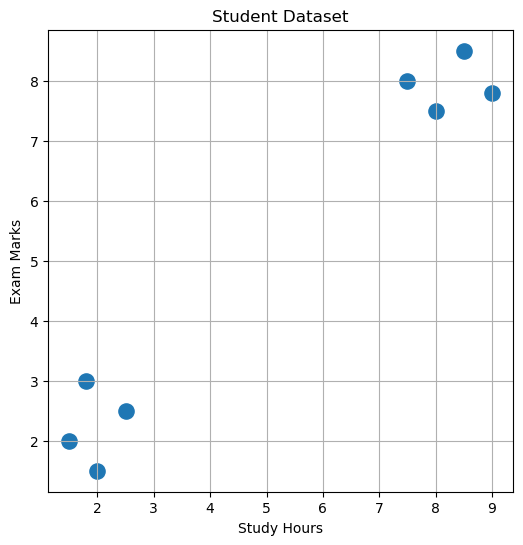

In [3]:
plt.figure(figsize=(6,6))

plt.scatter(X[:,0],X[:,1],s=120)

plt.xlabel("Study Hours")
plt.ylabel("Exam Marks")

plt.title("Student Dataset")

plt.grid(True)

plt.show()

# Observation

From the scatter plot, we can visually identify two groups.

However, the computer cannot identify these groups automatically.

The algorithm needs a starting point.

This starting point is called the **Initial Centroid**.

# What is a Centroid?

A centroid is the center of a cluster.

Initially, K-Means does not know where the clusters are located.

Therefore, it starts with random guesses.

For this notebook, we will manually choose two initial centroids.

Centroid 0

(2,2)

Centroid 1

(8,8)

These are only initial guesses.

The algorithm will gradually move them toward better locations.

In [4]:
c0 = np.array([2,2])
c1 = np.array([8,8])

print("Centroid 0 :", c0)
print("Centroid 1 :", c1)

Centroid 0 : [2 2]
Centroid 1 : [8 8]


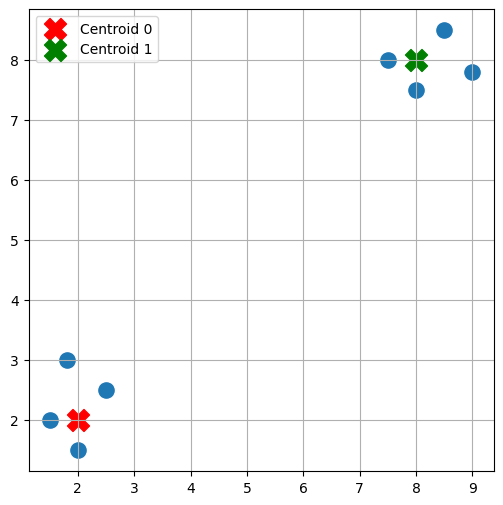

In [5]:
plt.figure(figsize=(6,6))

plt.scatter(X[:,0],X[:,1],s=120)

plt.scatter(c0[0],c0[1],
            color="red",
            marker="X",
            s=250,
            label="Centroid 0")

plt.scatter(c1[0],c1[1],
            color="green",
            marker="X",
            s=250,
            label="Centroid 1")

plt.legend()

plt.grid(True)

plt.show()

# What Happens Next?

The algorithm now performs the following steps repeatedly.

### Step 1

Calculate the distance between every data point and every centroid.

### Step 2

Assign each point to the nearest centroid.

### Step 3

Calculate the new centroid by taking the average of all assigned points.

### Step 4

Repeat these steps until the centroids stop moving.

This repeated process is called **Iteration**.

# Euclidean Distance
The distance between two points is calculated using the **Euclidean Distance** formula:

$$Distance = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

where:
* $(x_1, y_1)$ is the coordinate of the **data point**.
* $(x_2, y_2)$ is the coordinate of the **the centroid**.

The centroid that has the **minimum distance** becomes the "owner" of that specific data point.

# Manual Distance Calculation

Let us calculate the distance of the first student manually.

### Student Coordinates:
$$(x_1, y_1) = (1.5, 2)$$

---

### 1. Distance to Centroid 0
* **Centroid 0 $(x_2, y_2)$:** $(2, 2)$

$$d_0 = \sqrt{(2 - 1.5)^2 + (2 - 2)^2}$$
$$d_0 = \sqrt{(0.5)^2 + (0)^2}$$
$$d_0 = \sqrt{0.25}$$
$$d_0 = 0.5$$

---

### 2. Distance to Centroid 1
* **Centroid 1 $(x_2, y_2)$:** $(8, 8)$

$$d_1 = \sqrt{(8 - 1.5)^2 + (8 - 2)^2}$$
$$d_1 = \sqrt{(6.5)^2 + (6)^2}$$
$$d_1 = \sqrt{42.25 + 36}$$
$$d_1 = \sqrt{78.25}$$
$$d_1 \approx 8.85$$

---

### Conclusion:
Since **$0.5 < 8.85$** ($d_0 < d_1$), Centroid 0 has the minimum distance. Therefore, this student belongs to **Cluster 0**.

In [6]:
labels=[]

print("Point\t\tDistance to C0\tDistance to C1\tAssigned Cluster")

for point in X:

    d0=np.sqrt((point[0]-c0[0])**2+(point[1]-c0[1])**2)

    d1=np.sqrt((point[0]-c1[0])**2+(point[1]-c1[1])**2)

    if d0<d1:
        labels.append(0)
        cluster=0
    else:
        labels.append(1)
        cluster=1

    print(f"{point}\t{d0:.2f}\t\t{d1:.2f}\t\t{cluster}")

labels=np.array(labels)

Point		Distance to C0	Distance to C1	Assigned Cluster
[1.5 2. ]	0.50		8.85		0
[2.  1.5]	0.50		8.85		0
[2.5 2.5]	0.71		7.78		0
[1.8 3. ]	1.02		7.96		0
[7.5 8. ]	8.14		0.50		1
[8.  7.5]	8.14		0.50		1
[8.5 8.5]	9.19		0.71		1
[9.  7.8]	9.09		1.02		1


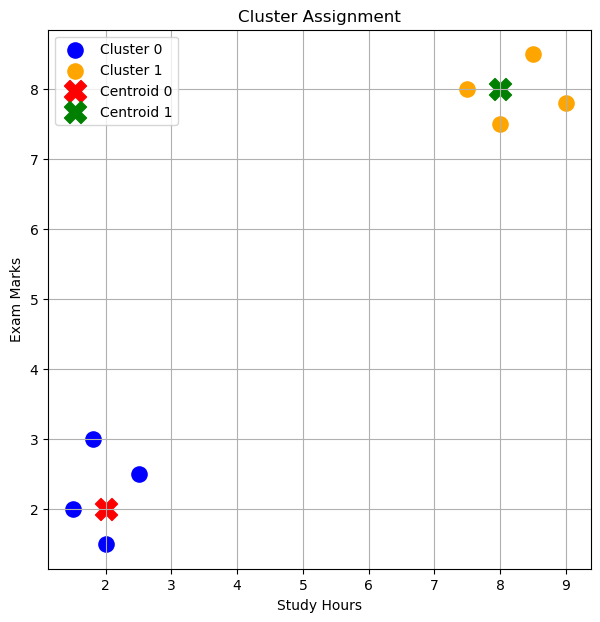

In [7]:
plt.figure(figsize=(7,7))

plt.scatter(
    X[labels==0][:,0],
    X[labels==0][:,1],
    color="blue",
    s=120,
    label="Cluster 0"
)

plt.scatter(
    X[labels==1][:,0],
    X[labels==1][:,1],
    color="orange",
    s=120,
    label="Cluster 1"
)

plt.scatter(
    c0[0],
    c0[1],
    color="red",
    marker="X",
    s=250,
    label="Centroid 0"
)

plt.scatter(
    c1[0],
    c1[1],
    color="green",
    marker="X",
    s=250,
    label="Centroid 1"
)

plt.xlabel("Study Hours")
plt.ylabel("Exam Marks")

plt.title("Cluster Assignment")

plt.legend()

plt.grid(True)

plt.show()

# Phase 2 : Updating the Centroids

The current centroids were only initial guesses.

Now we calculate a better centroid.

The new centroid is obtained by calculating the average of all points assigned to the cluster.

This process is called the **Maximization Step (M-Step)**.

# Why Mean?

Suppose **Cluster 0** contains the following 4 student points:

| Study Hours ($x$) | Marks ($y$) |
| :--- | :--- |
| 1.5 | 2.0 |
| 2.0 | 1.5 |
| 2.5 | 2.5 |
| 1.8 | 3.0 |

---

### 1. New X-Coordinate (Average Study Hours)
$$\mu_x = \frac{1.5 + 2.0 + 2.5 + 1.8}{4} = \frac{7.8}{4} = 1.95$$

### 2. New Y-Coordinate (Average Marks)
$$\mu_y = \frac{2.0 + 1.5 + 2.5 + 3.0}{4} = \frac{9.0}{4} = 2.25$$

---

### Conclusion:
The updated position for **Centroid 0** becomes:
$$(x_2, y_2) = (1.95, 2.25)$$

Hence the name **K-Means**, because each cluster's centerpoint is explicitly updated by calculating the mathematical **Mean** (average) of all the coordinate points that belong to it!

# Observation

Notice that the centroids have moved.

The new centroids better represent the center of each cluster.

The algorithm will now repeat the same steps again.

1. Calculate distances using the new centroids.
2. Assign clusters again.
3. Calculate new centroids again.

This continues until the centroids stop moving.

That point is called **Convergence**.

In [ ]:
centroids = np.array([c0, c1])

iteration = 1

while True:

    print("="*50)
    print(f"Iteration {iteration}")
    print("="*50)

    labels = []

    for point in X:

        distances = []

        for centroid in centroids:

            distance = np.sqrt(np.sum((point-centroid)**2))

            distances.append(distance)

        labels.append(np.argmin(distances))

    labels = np.array(labels)

    new_centroids = []

    for i in range(len(centroids)):

        cluster = X[labels==i]

        centroid = np.mean(cluster,axis=0)

        new_centroids.append(centroid)

    new_centroids=np.array(new_centroids)

    print("Old Centroids")
    print(centroids)

    print()

    print("New Centroids")
    print(new_centroids)

    print()

    if np.allclose(centroids,new_centroids):

        print("Converged Successfully")

        break

    centroids=new_centroids

    iteration+=1

Iteration 1
Old Centroids
[[2 2]
 [8 8]]

New Centroids
[[1.95 2.25]
 [8.25 7.95]]

Iteration 2
Old Centroids
[[1.95 2.25]
 [8.25 7.95]]

New Centroids
[[1.95 2.25]
 [8.25 7.95]]

Converged Successfully


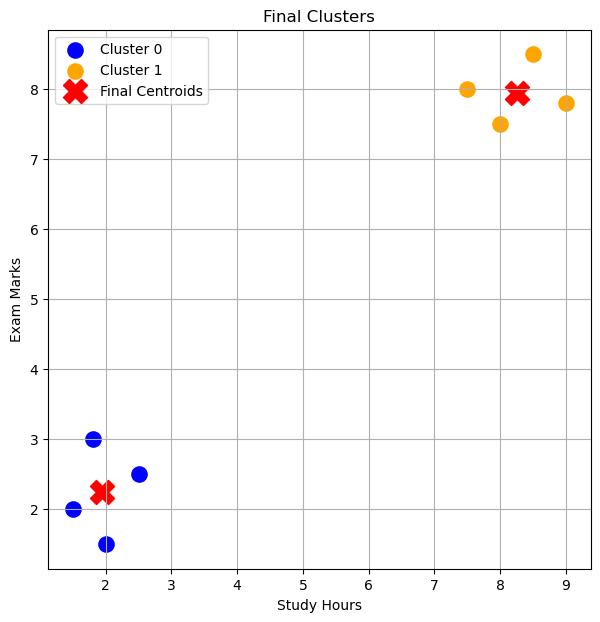

In [9]:
plt.figure(figsize=(7,7))

colors=["blue","orange"]

for i in range(2):

    plt.scatter(
        X[labels==i][:,0],
        X[labels==i][:,1],
        s=120,
        color=colors[i],
        label=f"Cluster {i}"
    )

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker="X",
    s=300,
    color="red",
    label="Final Centroids"
)

plt.xlabel("Study Hours")

plt.ylabel("Exam Marks")

plt.title("Final Clusters")

plt.grid(True)

plt.legend()

plt.show()

# Cost Function (Inertia)

How does K-Means know whether its clustering structure is good or bad? 

It evaluates performance by minimizing a total error metric called the **Within-Cluster Sum of Squares (WCSS)**, also frequently referred to in libraries like `scikit-learn` as **Inertia**.

### The Mathematical Objective:
The optimization objective of the K-Means algorithm is to minimize:

$$\boxed{WCSS = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2}$$

where:
* **$K$** = Total number of clusters selected.
* **$C_i$** = The set of all data points assigned to Cluster $i$.
* **$\mu_i$** = The coordinate vector of the **Centroid** of Cluster $i$.
* **$\|x - \mu_i\|^2$** = The **Squared Euclidean Distance** between a data point $x$ and its assigned centroid.

---

* **Smaller WCSS** means data points are tightly packed around their respective centers, indicating **higher quality, dense clusters**.
* Every single time K-Means updates its centroids by moving them to the mean of their points, this total WCSS value drops. The algorithm terminates when the WCSS cannot be reduced any further.

# Manual Example of WCSS

Let's walk through a quick, manual calculation of WCSS for a single cluster to see how the numbers work.

### 1. Given Inputs:
* **Assigned Data Points ($x$):** $(2, 2)$ and $(3, 3)$
* **Cluster Centroid ($\mu$):** $(2.5, 2.5)$

---

### 2. Squared Distance for the First Point:
$$\|x_1 - \mu\|^2 = (2 - 2.5)^2 + (2 - 2.5)^2$$
$$\|x_1 - \mu\|^2 = (-0.5)^2 + (-0.5)^2$$
$$\|x_1 - \mu\|^2 = 0.25 + 0.25 = 0.5$$

*(Note: We do not take the square root because the WCSS formula explicitly asks for the **squared** Euclidean distance!)*

---

### 3. Squared Distance for the Second Point:
$$\|x_2 - \mu\|^2 = (3 - 2.5)^2 + (3 - 2.5)^2$$
$$\|x_2 - \mu\|^2 = (0.5)^2 + (0.5)^2$$
$$\|x_2 - \mu\|^2 = 0.25 + 0.25 = 0.5$$

---

### 4. Total WCSS for this Cluster:
$$WCSS = \sum \|x - \mu\|^2 = 0.5 + 0.5 = 1.0$$

---

### Conclusion:
The smaller this overall total value becomes across all clusters, the closer the data points are to their assigned centers, and **the better the final clustering quality**.

In [10]:
wcss = 0

for i in range(len(centroids)):

    cluster = X[labels==i]

    for point in cluster:

        distance = np.sum((point-centroids[i])**2)

        wcss += distance

print("Final WCSS =",wcss)

Final WCSS = 3.5599999999999996


# K-Means Clustering

# Choosing the Value of K

One of the most common questions in K-Means is

> **How many clusters should we create?**

This value is represented by **K**.

Examples

- K = 2 → Two clusters
- K = 3 → Three clusters
- K = 5 → Five clusters

Choosing a very small or very large value of K may produce poor clustering results.

Therefore, we need a systematic way to determine the optimal value of K.

# The Elbow Method

The most popular method for selecting the value of **K** is called the **Elbow Method**.

The basic idea is simple.

1. Train K-Means using K = 1
2. Calculate WCSS
3. Train using K = 2
4. Calculate WCSS again
5. Continue for larger values of K

As K increases,

- WCSS always decreases.
- After a certain point, the improvement becomes very small.

This point is called the **Elbow Point**.

The corresponding value of K is usually selected as the optimal number of clusters.

In [17]:
import os

os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.cluster import KMeans

wcss = []

for k in range(1,8):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X)

    wcss.append(model.inertia_)

print(wcss)

[147.92000000000002, 3.5599999999999996, 2.4, 1.2400000000000002, 0.8700000000000001, 0.6200000000000001, 0.25]


c:\Users\DEE\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DEE\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DEE\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DEE\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

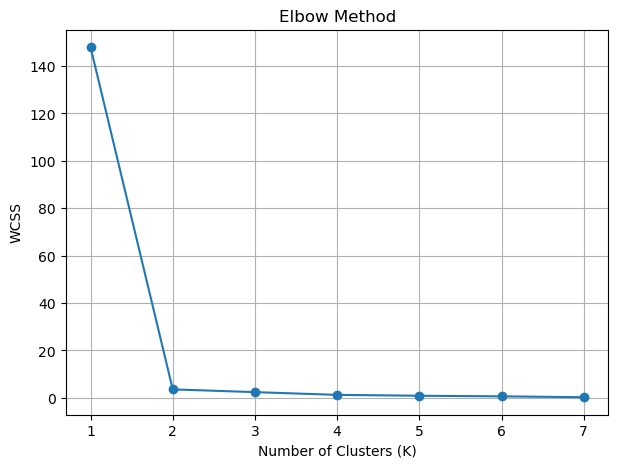

In [13]:
plt.figure(figsize=(7,5))

plt.plot(range(1,8),wcss,marker="o")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

# What is K-Means++?

One drawback of the original K-Means algorithm is that it chooses the initial centroids randomly.

Poor initial centroids may lead to

- Slow convergence
- Poor clustering
- Different results each time

To overcome this problem,

**K-Means++** was introduced.

# K-Means++ Algorithm

Instead of selecting all centroids randomly,

K-Means++ works as follows.

### Step 1

Randomly choose the first centroid.

### Step 2

Calculate the distance of every point from the chosen centroid.

### Step 3

Points farther away have a higher probability of becoming the next centroid.

### Step 4

Repeat until K centroids are selected.

This usually produces much better initial centroids.

# Implementing K-Means using Scikit-Learn

In [14]:
from sklearn.cluster import KMeans


model = KMeans(
    n_clusters=2,
    random_state=42
)

model.fit(X)

c:\Users\DEE\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [15]:
print("Cluster Labels")

print(model.labels_)

print()

print("Cluster Centers")

print(model.cluster_centers_)

Cluster Labels
[0 0 0 0 1 1 1 1]

Cluster Centers
[[1.95 2.25]
 [8.25 7.95]]


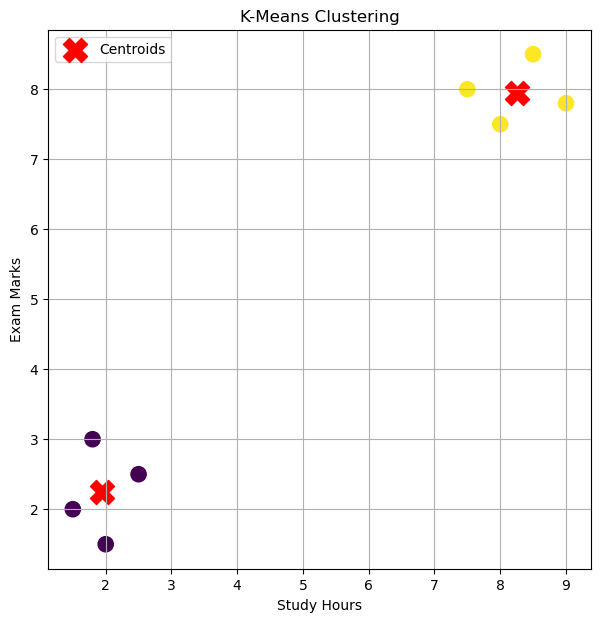

In [16]:
plt.figure(figsize=(7,7))

plt.scatter(
    X[:,0],
    X[:,1],
    c=model.labels_,
    cmap="viridis",
    s=120
)

plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[:,1],
    marker="X",
    color="red",
    s=300,
    label="Centroids"
)

plt.xlabel("Study Hours")

plt.ylabel("Exam Marks")

plt.title("K-Means Clustering")

plt.grid(True)

plt.legend()

plt.show()

# Limitations of K-Means

- The value of K must be chosen beforehand.
- Sensitive to outliers.
- Sensitive to initial centroid selection.
- Assumes clusters are roughly spherical.
- May converge to a local optimum.
- Does not perform well on non-spherical clusters.